# Patient0200 MedSAM 点标注分割完整训练流程

本 Notebook 展示使用 Patient0200 数据进行 MedSAM 点提示分割的完整训练过程，包括数据加载、模型推理、损失计算、训练循环和结果评估。

## 1. 加载预训练模型与数据

导入必要的库（PyTorch、NumPy、OpenCV、Matplotlib）并加载 MedSAM 预训练模型。设置设备（CUDA/CPU）并配置超参数。

In [73]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import cv2
from pathlib import Path
from matplotlib import pyplot as plt
from torch.nn import functional as F
from datetime import datetime
import nibabel as nib

# 设置工作目录
base_dir = Path(r"D:\HP\OneDrive\Desktop\学校\项目\超声图分割")
sys.path.append(str(base_dir / "MedSAM"))

# 从 segment_anything 导入模型
from segment_anything import sam_model_registry

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 配置超参数
CONFIG = {
    "image_size": 1024,
    "mask_decoder_size": 256,
    "batch_size": 4,
    "learning_rate": 0.00005,
    "weight_decay": 0.01,
    "max_epochs": 10,  # 仅做演示
    "boundary_weight": 0.1,
}

print(f"超参数配置: {CONFIG}")

使用设备: cuda
超参数配置: {'image_size': 1024, 'mask_decoder_size': 256, 'batch_size': 4, 'learning_rate': 5e-05, 'weight_decay': 0.01, 'max_epochs': 10, 'boundary_weight': 0.1}


In [74]:
# 加载预训练 MedSAM 模型
medsam_pretrained_path = base_dir / "MedSAM" / "work_dir" / "MedSAM" / "medsam_vit_b.pth"
medsam_ckpt_path = base_dir / "MedSAM" / "work_dir" / "camus_point" / "medsam_point_prompt_best.pth"

print(f"预训练模型路径: {medsam_pretrained_path}")
print(f"微调权重路径: {medsam_ckpt_path}")

# 加载预训练的 SAM 模型
sam_model = sam_model_registry["vit_b"](checkpoint=str(medsam_pretrained_path))
sam_model = sam_model.to(device)
sam_model.eval()

# 如果存在微调权重，加载它
if medsam_ckpt_path.exists():
    checkpoint = torch.load(str(medsam_ckpt_path), map_location=device)
    sam_model.load_state_dict(checkpoint["model"], strict=False)
    print(f"✓ 已加载微调权重")
else:
    print(f"⚠ 未找到微调权重，使用预训练模型")

print(f"✓ 模型加载成功，大小: {sum(p.numel() for p in sam_model.parameters()):,} 参数")

预训练模型路径: D:\HP\OneDrive\Desktop\学校\项目\超声图分割\MedSAM\work_dir\MedSAM\medsam_vit_b.pth
微调权重路径: D:\HP\OneDrive\Desktop\学校\项目\超声图分割\MedSAM\work_dir\camus_point\medsam_point_prompt_best.pth
✓ 已加载微调权重
✓ 模型加载成功，大小: 93,735,472 参数


## 2. 准备点标注数据

从 NPZ 文件加载 Patient0200 的点标注坐标和标签。从 NII.GZ 文件加载多类别地面真实标注。对图像进行预处理。

In [75]:
# 定义颜色和类别标签
CLASS_LABELS = {
    0: "Background",
    1: "Left Ventricle (LV)",
    2: "Myocardium (Myo)",
    3: "Right Ventricle (RV)",
}

CLASS_COLORS = {
    0: (0, 0, 0),        # 黑色 - 背景
    1: (255, 0, 0),      # 红色 - LV
    2: (0, 255, 0),      # 绿色 - Myo
    3: (0, 0, 255),      # 蓝色 - RV
}

# 加载 Patient0200 的图像
img_path = base_dir / "resource" / "数据处理" / "point_annotations" / "imgs" / "patient0200_patient0200_2CH_ED.npy"
pt_path = base_dir / "resource" / "数据处理" / "point_annotations" / "pts" / "patient0200_patient0200_2CH_ED.npz"

print(f"图像路径: {img_path}")
print(f"点标注路径: {pt_path}")

# 加载图像和点标注
image_raw = np.load(str(img_path))
pt_data = np.load(str(pt_path), allow_pickle=True)
coords_raw = pt_data["point_coords"]
labels_raw = pt_data["point_labels"]

print(f"✓ 图像加载成功: shape={image_raw.shape}, dtype={image_raw.dtype}")
print(f"✓ 点标注加载成功: coords shape={coords_raw.shape}, labels shape={labels_raw.shape}")
print(f"  前三个点坐标:\n{coords_raw[:3]}")
print(f"  前三个点标签: {labels_raw[:3]}")

图像路径: D:\HP\OneDrive\Desktop\学校\项目\超声图分割\resource\数据处理\point_annotations\imgs\patient0200_patient0200_2CH_ED.npy
点标注路径: D:\HP\OneDrive\Desktop\学校\项目\超声图分割\resource\数据处理\point_annotations\pts\patient0200_patient0200_2CH_ED.npz
✓ 图像加载成功: shape=(590, 487), dtype=float64
✓ 点标注加载成功: coords shape=(3, 2), labels shape=(3,)
  前三个点坐标:
[[227 322]
 [157 242]
 [326 351]]
  前三个点标签: [1. 2. 3.]


In [76]:
# 加载多类别 GT 从 database_nifti
gt_nifti_path = base_dir / "resource" / "CAMUS_public" / "database_nifti" / "patient0200" / "patient0200_2CH_ED_gt.nii.gz"

if gt_nifti_path.exists():
    gt_nifti = nib.load(str(gt_nifti_path))
    gt_multi_class = gt_nifti.get_fdata().astype(np.uint8)
    if gt_multi_class.ndim == 3:
        gt_multi_class = gt_multi_class[:, :, gt_multi_class.shape[2] // 2]
    print(f"✓ GT 加载成功: shape={gt_multi_class.shape}")
    print(f"  GT 类别: {np.unique(gt_multi_class)}")
else:
    print(f"⚠ 未找到 GT 文件: {gt_nifti_path}")
    gt_multi_class = None

# 图像预处理函数
def preprocess_image(image: np.ndarray, target_size=1024):
    """
    将图像规范化并调整到目标大小
    """
    # 转换为 float32
    image = image.astype(np.float32)
    
    # 如果是灰度图，转换为 RGB
    if image.ndim == 2:
        image_rgb = np.stack([image, image, image], axis=2)
    else:
        image_rgb = image
    
    # 归一化到 [0, 1]
    if image_rgb.max() > 1.0:
        image_rgb = (image_rgb - image_rgb.min()) / (image_rgb.max() - image_rgb.min() + 1e-8)
    
    # 调整大小
    image_resized = cv2.resize(image_rgb, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    
    return image_resized

# 预处理图像
image_processed = preprocess_image(image_raw, CONFIG["image_size"])
print(f"✓ 图像预处理成功: shape={image_processed.shape}, range=[{image_processed.min():.3f}, {image_processed.max():.3f}]")

# Shared helpers for SRAD soft boundary guidance
def to_uint8_gray(image: np.ndarray) -> np.ndarray:
    if image.max() <= 1.0:
        image_uint8 = (image * 255.0).astype(np.uint8)
    else:
        image_uint8 = image.astype(np.uint8)
    if image_uint8.ndim == 2:
        return image_uint8
    return cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)

def normalize01(x: np.ndarray) -> np.ndarray:
    x_min = x.min()
    x_max = x.max()
    return (x - x_min) / (x_max - x_min + 1e-8)

def srad_filter(image: np.ndarray, num_iter=20, delta_t=0.15, kappa=15) -> np.ndarray:
    """SRAD filtering for speckle noise reduction in ultrasound images"""
    img = image.astype(np.float64).copy()
    for _ in range(num_iter):
        grad_N = np.roll(img, -1, axis=0) - img
        grad_S = np.roll(img, 1, axis=0) - img
        grad_E = np.roll(img, 1, axis=1) - img
        grad_W = np.roll(img, -1, axis=1) - img
        grad_mag = np.sqrt(grad_N**2 + grad_S**2 + grad_E**2 + grad_W**2 + 1e-10)
        q = grad_mag / (img + 1e-10)
        q0 = np.sqrt(np.mean(q**2))
        c = 1.0 / (1.0 + ((q**2 - q0**2) / (q0**2 * (kappa**2) + 1e-10)))
        cN = np.roll(c, -1, axis=0)
        cS = np.roll(c, 1, axis=0)
        cE = np.roll(c, 1, axis=1)
        cW = np.roll(c, -1, axis=1)
        img = img + delta_t * (cN * grad_N + cS * grad_S + cE * grad_E + cW * grad_W)
    return img

def build_soft_boundary(
    image_gray: np.ndarray,
    num_iter=20,
    delta_t=0.15,
    kappa=15,
    var_ksize=7,
    grad_ksize=3,
    mix_grad=0.7,
):
    img_norm = image_gray.astype(np.float64) / 255.0
    img_srad = srad_filter(img_norm, num_iter=num_iter, delta_t=delta_t, kappa=kappa)
    grad_x = cv2.Sobel(img_srad, cv2.CV_64F, 1, 0, ksize=grad_ksize)
    grad_y = cv2.Sobel(img_srad, cv2.CV_64F, 0, 1, ksize=grad_ksize)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    grad_norm = normalize01(grad_mag)
    mean = cv2.blur(img_srad, (var_ksize, var_ksize))
    mean_sq = cv2.blur(img_srad**2, (var_ksize, var_ksize))
    var_map = mean_sq - mean**2
    var_norm = normalize01(var_map)
    soft_boundary = normalize01(mix_grad * grad_norm + (1.0 - mix_grad) * var_norm)
    return soft_boundary, img_srad, grad_norm, var_norm

✓ GT 加载成功: shape=(590, 487)
  GT 类别: [0 1 2 3]
✓ 图像预处理成功: shape=(1024, 1024, 3), range=[0.000, 0.999]


## 3. 点提示分割推理

使用单个点坐标进行推理，获取模型的概率输出。处理多个点的推理结果。

In [77]:
# 图像编码函数
def encode_image_for_sam(image: np.ndarray, sam_model, device):
    """
    将图像编码为 SAM 模型的嵌入
    """
    # 转换为张量并添加 batch 维度
    image_tensor = torch.tensor(image).permute(2, 0, 1).unsqueeze(0).to(device).float()
    
    with torch.no_grad():
        image_embedding = sam_model.image_encoder(image_tensor)
    
    return image_embedding

# 单点推理函数
def infer_single_point(sam_model, image_embedding, point_x, point_y, point_label=1, 
                      image_size=1024, mask_size=256, device="cuda"):
    """
    使用单个点进行分割推理
    """
    # 将点坐标转换为 1024x1024 空间
    coords_1024 = np.array([[[point_x * image_size / image_raw.shape[1], 
                             point_y * image_size / image_raw.shape[0]]]], dtype=np.float32)
    
    coords_torch = torch.tensor(coords_1024, dtype=torch.float32, device=device)
    labels_torch = torch.tensor([[int(point_label)]], dtype=torch.long, device=device)
    
    with torch.no_grad():
        # 获取点提示嵌入
        sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
            points=(coords_torch, labels_torch),
            boxes=None,
            masks=None,
        )
        
        # 解码获得分割结果
        low_res_logits, _ = sam_model.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=sam_model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        
        # 得到原始大小的预测
        low_res_probs = torch.sigmoid(low_res_logits)
        
        # 调整回原始图像大小
        H, W = image_raw.shape[:2]
        pred = F.interpolate(low_res_probs, size=(H, W), mode="bilinear", align_corners=False)
        pred = pred.detach().cpu().numpy().squeeze()
    
    return pred

# 编码图像
print("正在对输入图像进行编码...")
image_tensor = torch.tensor(image_processed).permute(2, 0, 1).unsqueeze(0).to(device).float()
image_embedding = encode_image_for_sam(image_processed, sam_model, device)
print(f"✓ 图像编码成功: embedding shape={image_embedding.shape}")

# 对前三个点进行推理
print("\n对前三个点进行推理...")
coords_raw_sample = coords_raw[:3]
labels_raw_sample = labels_raw[:3]

probs_pred = []
H, W = image_raw.shape[:2]

for i in range(3):
    x, y = float(coords_raw_sample[i, 0]), float(coords_raw_sample[i, 1])
    
    # 如果坐标已在像素空间，直接使用；否则放缩
    if coords_raw_sample.max() <= 1.0:
        x = x * W
        y = y * H
    
    label = int(labels_raw_sample[i]) if i < len(labels_raw_sample) else 1
    prob = infer_single_point(sam_model, image_embedding, x, y, point_label=label, device=device)
    probs_pred.append(prob)
    
    print(f"  点 {i+1}: 坐标=({x:.1f}, {y:.1f}), 标签={label}, 输出范围=[{prob.min():.4f}, {prob.max():.4f}]")

probs_stack = np.stack(probs_pred, axis=0)
print(f"\n✓ 推理成功: {len(probs_pred)} 个点的概率图堆叠 shape={probs_stack.shape}")

正在对输入图像进行编码...
✓ 图像编码成功: embedding shape=torch.Size([1, 256, 64, 64])

对前三个点进行推理...
  点 1: 坐标=(227.0, 322.0), 标签=1, 输出范围=[0.0000, 0.9910]
  点 2: 坐标=(157.0, 242.0), 标签=2, 输出范围=[0.0000, 0.9883]
  点 3: 坐标=(326.0, 351.0), 标签=3, 输出范围=[0.0000, 0.9997]

✓ 推理成功: 3 个点的概率图堆叠 shape=(3, 590, 487)


✓ Multi-point fusion complete:
  Class 1 (LV): 19013 pixels
  Class 2 (Myo): 5491 pixels
  Class 3 (RV): 6720 pixels


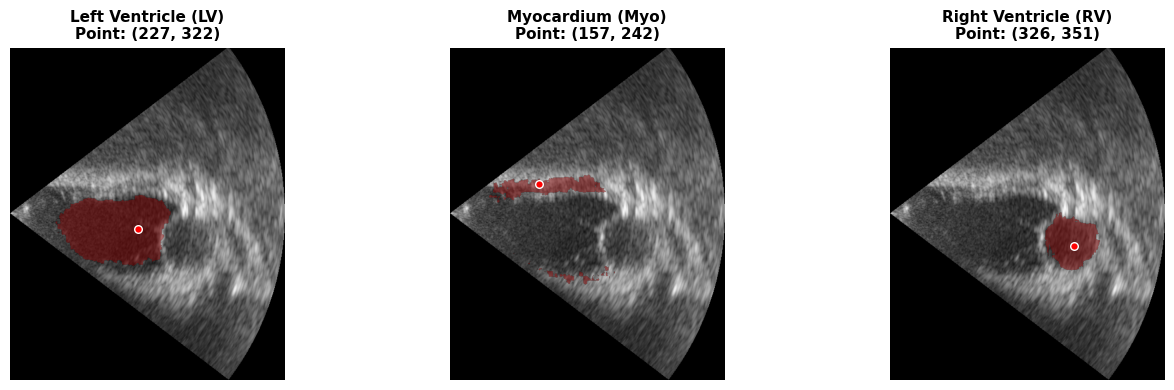


✓ Inference visualization complete


In [78]:
# 多点融合 - 互斥分配
weights = np.array([1, 0.8, 0.9], dtype=np.float32)  # Priority: LV > RV > Myo (Myo reduced)
weighted_probs = probs_stack * weights[:, None, None]
max_probs = weighted_probs.max(axis=0)
best_idx = weighted_probs.argmax(axis=0)

# 生成二值掩膜
masks_binary = [((best_idx == i) & (max_probs > 0.75)).astype(np.uint8) for i in range(3)]

# 生成多类别标签
pred_multi_label = np.zeros((H, W), dtype=np.uint8)
for i, mask in enumerate(masks_binary):
    pred_multi_label[mask > 0] = i + 1

print("✓ Multi-point fusion complete:")
print(f"  Class 1 (LV): {(pred_multi_label == 1).sum()} pixels")
print(f"  Class 2 (Myo): {(pred_multi_label == 2).sum()} pixels")
print(f"  Class 3 (RV): {(pred_multi_label == 3).sum()} pixels")

# 可视化推理结果
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i in range(3):
    ax = axes[i]
    
    # 显示原始图像
    ax.imshow(image_raw, cmap="gray")
    
    # 叠加掩膜
    mask_vis = np.ma.masked_where(masks_binary[i] == 0, masks_binary[i])
    ax.imshow(mask_vis, alpha=0.5, cmap="jet", vmin=0, vmax=1)
    
    # 标记点位置
    x, y = coords_raw_sample[i, 0], coords_raw_sample[i, 1]
    if coords_raw_sample.max() <= 1.0:
        x = x * W
        y = y * H
    ax.scatter([x], [y], c="red", s=30, marker="o", edgecolors="white", linewidths=1)
    
    ax.set_title(f"{CLASS_LABELS[i+1]}\nPoint: ({x:.0f}, {y:.0f})", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\n✓ Inference visualization complete")


Visualizing model feature maps and edge-like responses...



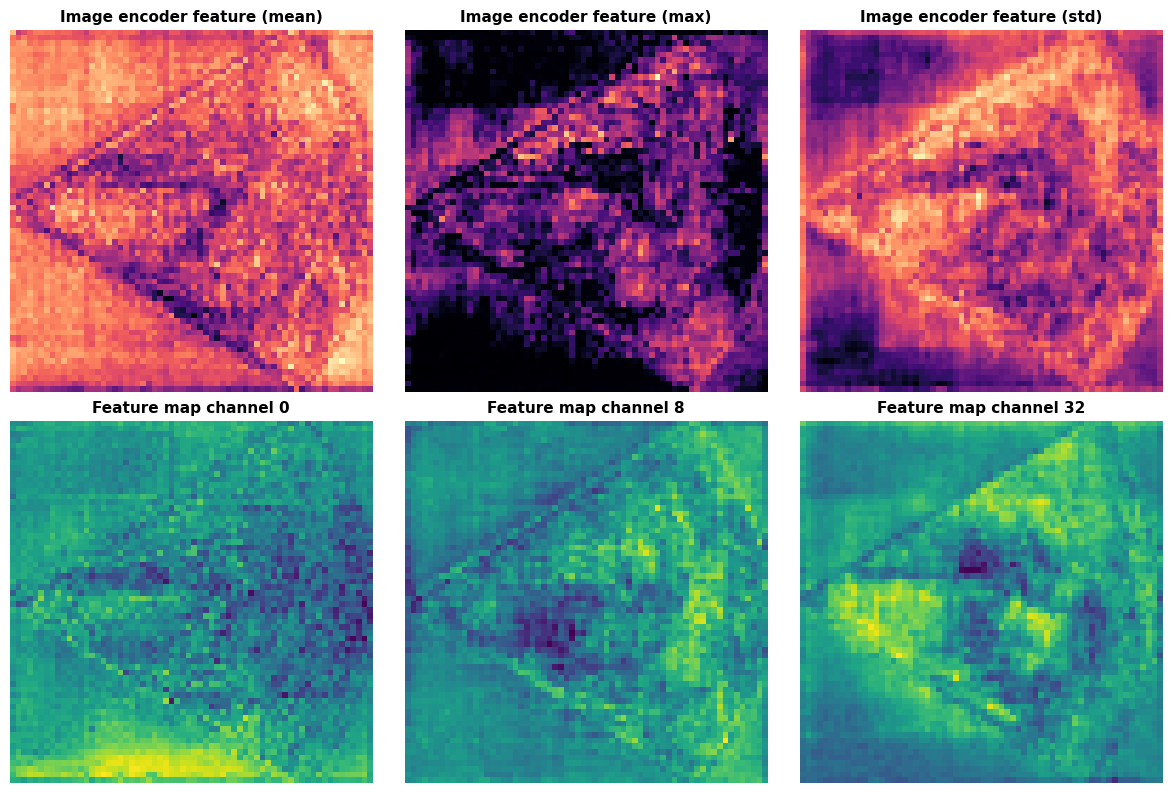

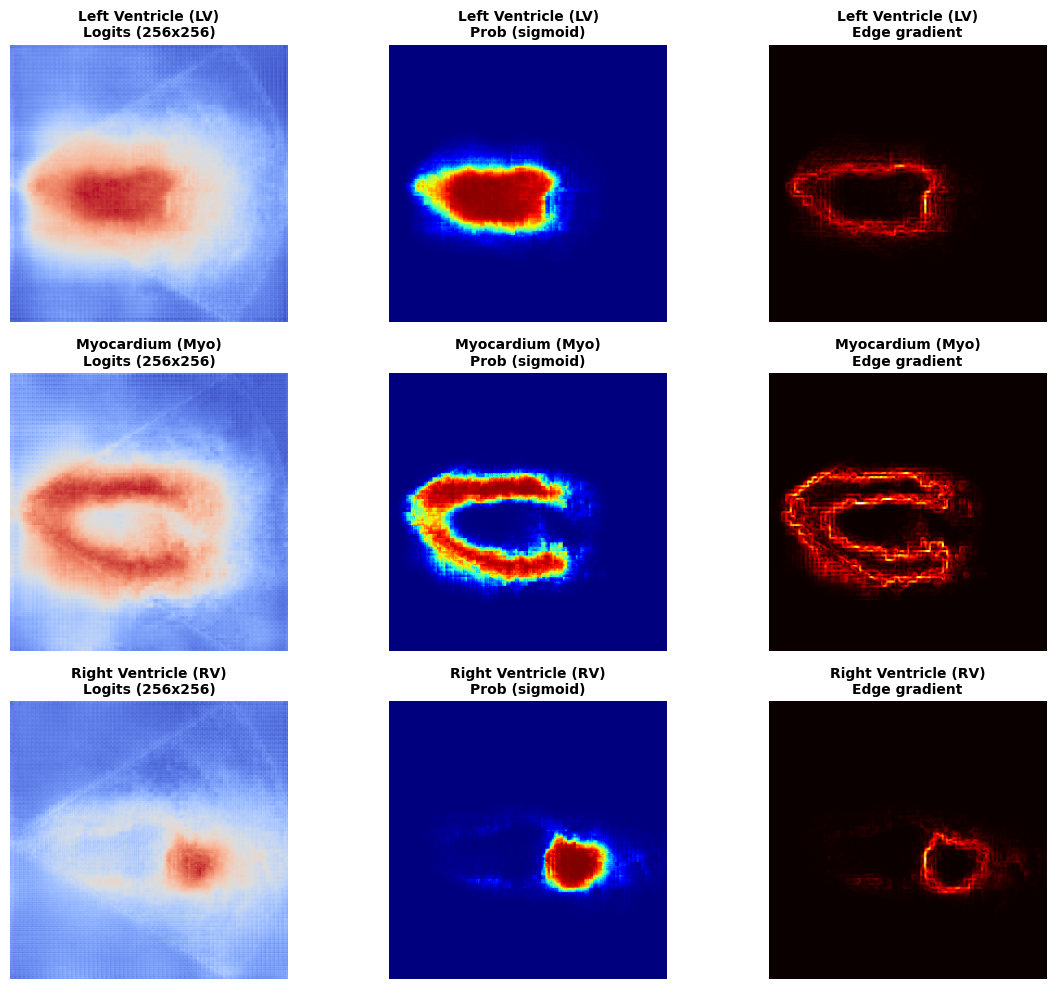

✓ Feature map and edge-like response visualizations complete (all 3 points)


In [79]:
# Visualize model outputs with edge-like information
print("\nVisualizing model feature maps and edge-like responses...\n")

# 1) Image encoder output (B, 256, 64, 64)
with torch.no_grad():
    image_tensor_enc = torch.tensor(image_processed).permute(2, 0, 1).unsqueeze(0).to(device).float()
    image_embedding = sam_model.image_encoder(image_tensor_enc)

# Convert to numpy for visualization
feat = image_embedding.squeeze(0).detach().cpu().numpy()  # (256, 64, 64)
feat_mean = feat.mean(axis=0)
feat_max = feat.max(axis=0)

# Pick a few channels to visualize
channel_indices = [0, 8, 32, 64]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(feat_mean, cmap="magma")
axes[0, 0].set_title("Image encoder feature (mean)", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(feat_max, cmap="magma")
axes[0, 1].set_title("Image encoder feature (max)", fontsize=11, fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(np.std(feat, axis=0), cmap="magma")
axes[0, 2].set_title("Image encoder feature (std)", fontsize=11, fontweight="bold")
axes[0, 2].axis("off")

for idx, ch in enumerate(channel_indices[:3]):
    ax = axes[1, idx]
    ax.imshow(feat[ch], cmap="viridis")
    ax.set_title(f"Feature map channel {ch}", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 2) Mask decoder low_res_logits and edge-like gradients for all three points
# Define Sobel kernels
kernel_x = torch.tensor(
    [[[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]]],
    device=device,
    dtype=torch.float32,
).unsqueeze(0)

kernel_y = torch.tensor(
    [[[-1.0, -2.0, -1.0], [0.0, 0.0, 0.0], [1.0, 2.0, 1.0]]],
    device=device,
    dtype=torch.float32,
).unsqueeze(0)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for point_idx in range(3):
    # Get point coordinates
    x_pt, y_pt = coords_raw_sample[point_idx]
    if coords_raw_sample.max() <= 1.0:
        x_pt = x_pt * W
        y_pt = y_pt * H
    
    coords_1024 = np.array([[[x_pt * 1024 / W, y_pt * 1024 / H]]], dtype=np.float32)
    coords_torch = torch.tensor(coords_1024, dtype=torch.float32, device=device)
    labels_torch = torch.tensor([[1]], dtype=torch.long, device=device)
    
    with torch.no_grad():
        sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
            points=(coords_torch, labels_torch),
            boxes=None,
            masks=None,
        )
        low_res_logits, _ = sam_model.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=sam_model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
    
    low_res_probs = torch.sigmoid(low_res_logits)
    
    # Compute gradient magnitude on low-res probs
    with torch.no_grad():
        grad_x = F.conv2d(low_res_probs, kernel_x, padding=1)
        grad_y = F.conv2d(low_res_probs, kernel_y, padding=1)
        grad_mag = torch.sqrt(grad_x**2 + grad_y**2 + 1e-8)
    
    low_res_logits_np = low_res_logits.squeeze().cpu().numpy()
    low_res_probs_np = low_res_probs.squeeze().cpu().numpy()
    grad_mag_np = grad_mag.squeeze().cpu().numpy()
    
    # Plot for this point
    axes[point_idx, 0].imshow(low_res_logits_np, cmap="coolwarm")
    axes[point_idx, 0].set_title(
        f"{CLASS_LABELS[point_idx+1]}\nLogits (256x256)", 
        fontsize=10, fontweight="bold"
    )
    axes[point_idx, 0].axis("off")
    
    axes[point_idx, 1].imshow(low_res_probs_np, cmap="jet", vmin=0, vmax=1)
    axes[point_idx, 1].set_title(
        f"{CLASS_LABELS[point_idx+1]}\nProb (sigmoid)", 
        fontsize=10, fontweight="bold"
    )
    axes[point_idx, 1].axis("off")
    
    axes[point_idx, 2].imshow(grad_mag_np, cmap="hot")
    axes[point_idx, 2].set_title(
        f"{CLASS_LABELS[point_idx+1]}\nEdge gradient", 
        fontsize=10, fontweight="bold"
    )
    axes[point_idx, 2].axis("off")

plt.tight_layout()
plt.show()

print("✓ Feature map and edge-like response visualizations complete (all 3 points)")

## 4. 损失函数定义与计算

实现点监督损失和边界对齐损失。演示不同损失函数的作用。

In [80]:
class PointSupervisionLoss(nn.Module):
    """点监督损失 - 仅在点位置计算损失"""
    
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction="mean")
    
    def forward(self, logits, coords, labels, image_size=1024):
        """
        Args:
            logits: 模型输出的原始分数, shape=(B, 1, H, W)
            coords: 点坐标, shape=(B, num_points, 2)
            labels: 点标签, shape=(B, num_points)
            image_size: 图像尺寸
        """
        if coords is None or labels is None:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        
        coords_use = coords.clone()
        if coords_use.max() <= 1.5:
            coords_use = coords_use * image_size
        
        labels_use = labels.float()
        if labels_use.ndim == 2:
            labels_use = labels_use.unsqueeze(-1)
        
        # 将坐标放缩到 logits 空间（256x256）
        scale = logits.shape[-1] / float(image_size)
        x = torch.round(coords_use[..., 0] * scale).long().clamp(0, logits.shape[-1] - 1)
        y = torch.round(coords_use[..., 1] * scale).long().clamp(0, logits.shape[-2] - 1)
        
        # 获取该点处的 logits
        batch_idx = torch.arange(logits.shape[0], device=logits.device).view(-1, 1)
        logits_pts = logits[batch_idx, 0, y, x]
        
        # 计算 BCE 损失
        loss = self.bce(logits_pts, labels_use.squeeze(-1))
        return loss


class BoundaryAlignmentLoss(nn.Module):
    """边界对齐损失 - 使用软边界权重进行引导"""
    
    def __init__(self):
        super().__init__()
    
    def forward(self, logits, boundary_weight=None):
        """
        Args:
            logits: 模型输出的原始分数, shape=(B, 1, H, W)
            boundary_weight: 软边界权重, shape=(B, 1, H, W), range=[0, 1]
        """
        if boundary_weight is None or boundary_weight.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        
        pred_probs = torch.sigmoid(logits)
        
        # Sobel 算子计算梯度
        kernel_x = torch.tensor(
            [[[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]]],
            device=pred_probs.device,
            dtype=pred_probs.dtype,
        ).unsqueeze(0)
        
        kernel_y = torch.tensor(
            [[[-1.0, -2.0, -1.0], [0.0, 0.0, 0.0], [1.0, 2.0, 1.0]]],
            device=pred_probs.device,
            dtype=pred_probs.dtype,
        ).unsqueeze(0)
        
        grad_x = F.conv2d(pred_probs, kernel_x, padding=1)
        grad_y = F.conv2d(pred_probs, kernel_y, padding=1)
        grad_mag = torch.sqrt(grad_x**2 + grad_y**2 + 1e-8)
        
        # 梯度归一化
        grad_max = grad_mag.view(grad_mag.shape[0], -1).max(dim=1)[0].clamp_min(1e-8)
        grad_max = grad_max.view(-1, 1, 1, 1)
        grad_norm = (grad_mag / grad_max).clamp(0.0, 1.0)
        
        # 软边界权重约束
        boundary_weight = boundary_weight.clamp(0.0, 1.0)
        loss = F.binary_cross_entropy(grad_norm, boundary_weight)
        return loss


# 初始化损失函数
point_loss_fn = PointSupervisionLoss()
boundary_loss_fn = BoundaryAlignmentLoss()

print("✓ 损失函数初始化成功")

✓ 损失函数初始化成功


In [81]:
# 演示损失计算
print("演示损失函数计算...\n")

# 创建一个假模型输出用于演示（256x256）
# 在实际训练中，这来自 mask_decoder 的输出
dummy_logits = torch.randn(1, 1, 256, 256, device=device)

# 准备点坐标和标签（转换到 1024x1024 空间）
coords_for_loss = np.array([[coords_raw_sample[0, 0] * 1024 / W,
                             coords_raw_sample[0, 1] * 1024 / H]], dtype=np.float32)
coords_torch = torch.tensor(coords_for_loss[None, ...], device=device, dtype=torch.float32)
labels_torch = torch.tensor([[1]], device=device, dtype=torch.long)

# 计算点监督损失
point_loss = point_loss_fn(dummy_logits, coords_torch, labels_torch, image_size=1024)
print(f"点监督损失 (PointSupervisionLoss): {point_loss.item():.6f}")

# 构建 SRAD 软边界权重（不使用二值 Canny）
img_gray = to_uint8_gray(image_raw)
soft_boundary, img_srad, grad_norm, var_norm = build_soft_boundary(
    img_gray, num_iter=20, delta_t=0.15, kappa=15, var_ksize=7, grad_ksize=3, mix_grad=0.7
 )
boundary_mask_256 = cv2.resize(soft_boundary.astype(np.float32), (256, 256))
boundary_mask_torch = torch.tensor(boundary_mask_256[None, None, ...], device=device, dtype=torch.float32)

# 计算边界对齐损失
boundary_loss = boundary_loss_fn(dummy_logits, boundary_mask_torch)
print(f"边界对齐损失 (BoundaryAlignmentLoss): {boundary_loss.item():.6f}")

# 计算总损失
total_loss = point_loss + CONFIG["boundary_weight"] * boundary_loss
print(f"\n总损失 (权重因子 α={CONFIG['boundary_weight']}): {total_loss.item():.6f}")
print(f"  = PointSupervisionLoss + {CONFIG['boundary_weight']} × BoundaryAlignmentLoss")
print(f"  = {point_loss.item():.6f} + {CONFIG['boundary_weight']} × {boundary_loss.item():.6f}")

演示损失函数计算...

点监督损失 (PointSupervisionLoss): 0.549958
边界对齐损失 (BoundaryAlignmentLoss): 0.393688

总损失 (权重因子 α=0.1): 0.589327
  = PointSupervisionLoss + 0.1 × BoundaryAlignmentLoss
  = 0.549958 + 0.1 × 0.393688



Visualizing loss components with SRAD soft boundary guidance...



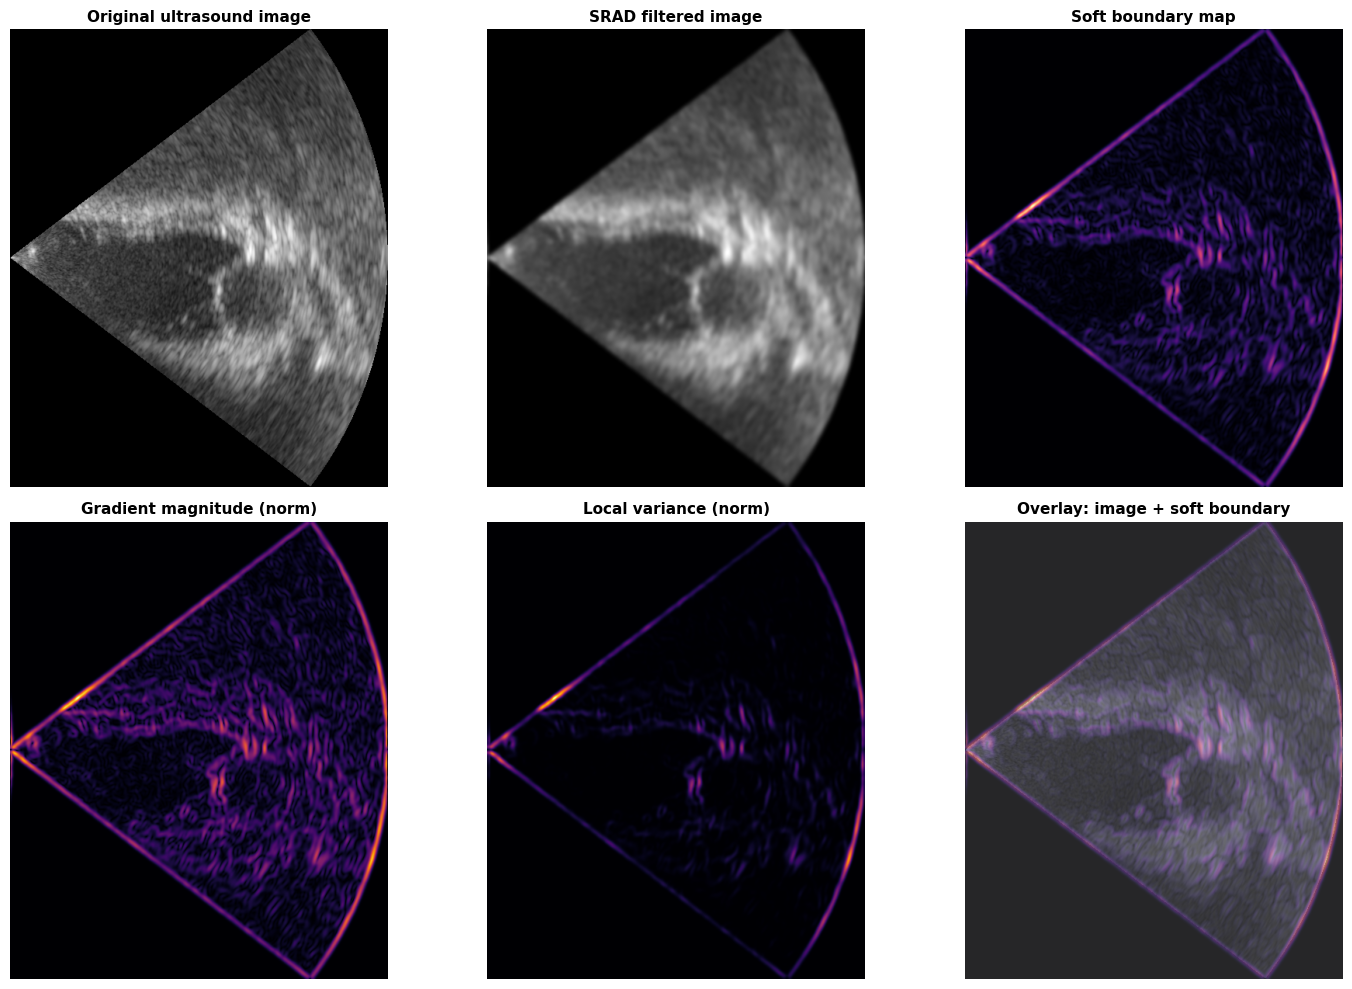


✓ Soft boundary guidance complete
  Soft boundary mean: 0.0504
  Soft boundary p95:  0.2027
  Soft boundary p99:  0.3962
  SRAD params: iter=20, kappa=15

✓ Updated boundary_mask_torch to use SRAD soft boundary guidance


In [82]:
# Visualize loss components with soft boundary guidance
print("\nVisualizing loss components with SRAD soft boundary guidance...\n")

# Build SRAD soft boundary map
img_gray = to_uint8_gray(image_raw)
soft_boundary, img_srad, grad_norm, var_norm = build_soft_boundary(
    img_gray, num_iter=20, delta_t=0.15, kappa=15, var_ksize=7, grad_ksize=3, mix_grad=0.7
 )
boundary_mask_256_soft = cv2.resize(soft_boundary.astype(np.float32), (256, 256))

# Create visualization figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image_raw, cmap="gray")
axes[0, 0].set_title("Original ultrasound image", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_srad, cmap="gray")
axes[0, 1].set_title("SRAD filtered image", fontsize=11, fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(soft_boundary, cmap="magma")
axes[0, 2].set_title("Soft boundary map", fontsize=11, fontweight="bold")
axes[0, 2].axis("off")

axes[1, 0].imshow(grad_norm, cmap="inferno")
axes[1, 0].set_title("Gradient magnitude (norm)", fontsize=11, fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(var_norm, cmap="inferno")
axes[1, 1].set_title("Local variance (norm)", fontsize=11, fontweight="bold")
axes[1, 1].axis("off")

axes[1, 2].imshow(image_raw, cmap="gray", alpha=0.7)
axes[1, 2].imshow(soft_boundary, cmap="magma", alpha=0.5)
axes[1, 2].set_title("Overlay: image + soft boundary", fontsize=11, fontweight="bold")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

soft_mean = float(soft_boundary.mean())
soft_p95 = float(np.percentile(soft_boundary, 95))
soft_p99 = float(np.percentile(soft_boundary, 99))
print(f"\n✓ Soft boundary guidance complete")
print(f"  Soft boundary mean: {soft_mean:.4f}")
print(f"  Soft boundary p95:  {soft_p95:.4f}")
print(f"  Soft boundary p99:  {soft_p99:.4f}")
print(f"  SRAD params: iter=20, kappa=15")

# Update boundary mask for training (soft weights)
boundary_mask_256 = boundary_mask_256_soft
boundary_mask_torch = torch.tensor(boundary_mask_256[None, None, ...], device=device, dtype=torch.float32)
print("\n✓ Updated boundary_mask_torch to use SRAD soft boundary guidance")


Visualizing point supervision sampling...



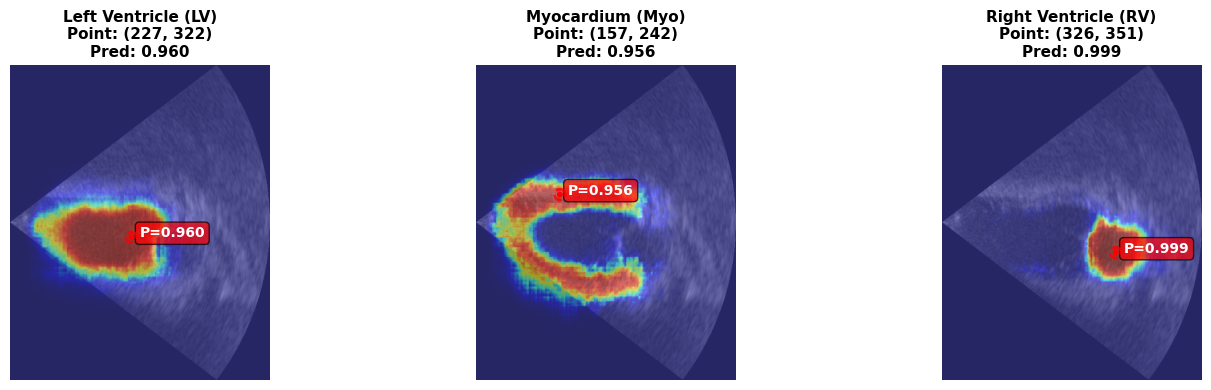

✓ Point supervision visualization complete

Legend:
  - Solid red dot: labeled point
  - Dashed red circle: sampling region (illustrative)
  - Heatmap: predicted probability
  - P value: probability at the point


In [83]:
# Visualize point supervision sampling
print("\nVisualizing point supervision sampling...\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Visualize three points
for i in range(3):
    ax = axes[i]
    
    # Show prediction probability map
    ax.imshow(image_raw, cmap="gray", alpha=0.7)
    ax.imshow(probs_pred[i], cmap="jet", alpha=0.5, vmin=0, vmax=1)
    
    # Point location
    x, y = coords_raw_sample[i]
    if coords_raw_sample.max() <= 1.0:
        x = x * W
        y = y * H
    
    # Point marker
    circle = plt.Circle((x, y), radius=3, color="red", fill=True, linewidth=2, zorder=10)
    ax.add_patch(circle)
    
    # Sampling region (illustrative)
    circle_area = plt.Circle(
        (x, y), radius=10, color="red", fill=False,
        linewidth=2, linestyle="--", alpha=0.8, zorder=9
    )
    ax.add_patch(circle_area)
    
    # Predicted value at point
    point_value = probs_pred[i][int(y), int(x)]
    
    ax.set_title(
        f"{CLASS_LABELS[i+1]}\nPoint: ({x:.0f}, {y:.0f})\nPred: {point_value:.3f}",
        fontsize=11,
        fontweight="bold",
    )
    ax.axis("off")
    
    # Inline annotation
    ax.text(
        x + 15, y, f"P={point_value:.3f}",
        color="white", fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="red", alpha=0.7)
    )

plt.tight_layout()
plt.show()

print("✓ Point supervision visualization complete")
print("\nLegend:")
print("  - Solid red dot: labeled point")
print("  - Dashed red circle: sampling region (illustrative)")
print("  - Heatmap: predicted probability")
print("  - P value: probability at the point")


Visualizing loss formulas...



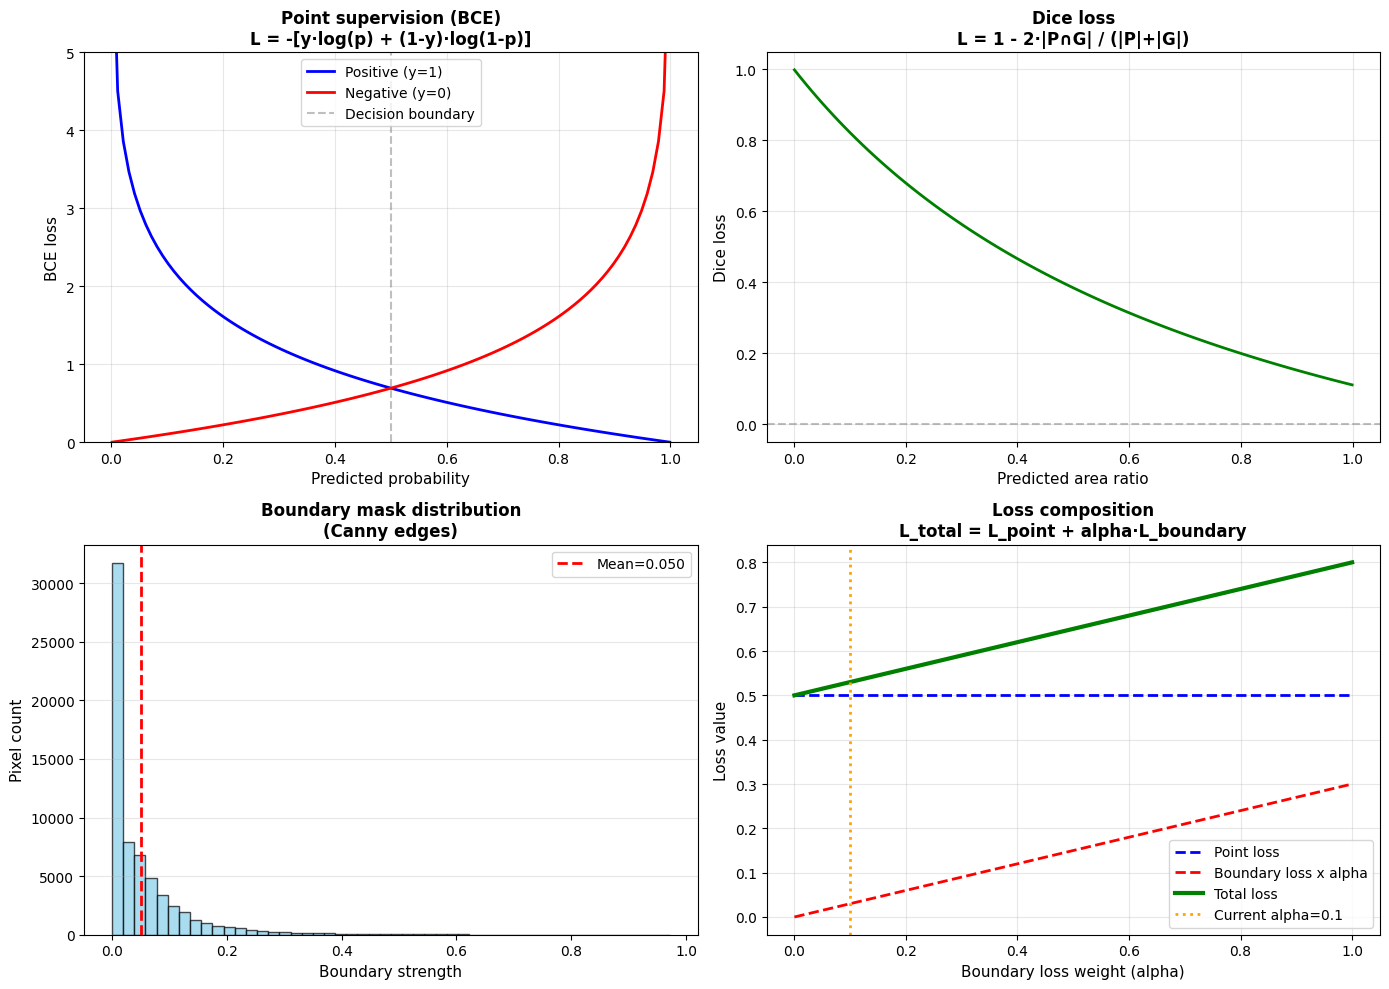

✓ Loss formula visualization complete

Notes:
  1. Point loss (BCE): computed only at labeled points
  2. Dice loss: global overlap metric (optional)
  3. Boundary loss: align edges, weight alpha=0.1
  4. Total loss: point loss + 0.1 x boundary loss


In [84]:
# Visualize the loss functions
print("\nVisualizing loss formulas...\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Point supervision - BCE curves
x_vals = np.linspace(0.001, 0.999, 100)
bce_loss_pos = -np.log(x_vals)  # positive label (y=1)
bce_loss_neg = -np.log(1 - x_vals)  # negative label (y=0)

axes[0, 0].plot(x_vals, bce_loss_pos, "b-", linewidth=2, label="Positive (y=1)")
axes[0, 0].plot(x_vals, bce_loss_neg, "r-", linewidth=2, label="Negative (y=0)")
axes[0, 0].axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Decision boundary")
axes[0, 0].set_xlabel("Predicted probability", fontsize=11)
axes[0, 0].set_ylabel("BCE loss", fontsize=11)
axes[0, 0].set_title(
    "Point supervision (BCE)\nL = -[y·log(p) + (1-y)·log(1-p)]",
    fontsize=12,
    fontweight="bold",
)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 5])

# 2. Dice loss curve (illustration)
intersection = x_vals * 0.8  # assume GT area 0.8
pred_sum = x_vals
gt_sum = 0.8
dice = (2 * intersection) / (pred_sum + gt_sum + 1e-7)
dice_loss = 1 - dice

axes[0, 1].plot(x_vals, dice_loss, "g-", linewidth=2)
axes[0, 1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[0, 1].set_xlabel("Predicted area ratio", fontsize=11)
axes[0, 1].set_ylabel("Dice loss", fontsize=11)
axes[0, 1].set_title(
    "Dice loss\nL = 1 - 2·|P∩G| / (|P|+|G|)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 1].grid(True, alpha=0.3)

# 3. Boundary mask distribution
boundary_hist = boundary_mask_256.flatten()
axes[1, 0].hist(boundary_hist, bins=50, color="skyblue", edgecolor="black", alpha=0.7)
axes[1, 0].axvline(
    x=boundary_hist.mean(), color="red", linestyle="--",
    linewidth=2, label=f"Mean={boundary_hist.mean():.3f}"
)
axes[1, 0].set_xlabel("Boundary strength", fontsize=11)
axes[1, 0].set_ylabel("Pixel count", fontsize=11)
axes[1, 0].set_title(
    "Boundary mask distribution\n(Canny edges)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis="y")

# 4. Loss weight composition
weights_range = np.linspace(0, 1, 100)
point_loss_const = 0.5
boundary_loss_const = 0.3
total_losses = point_loss_const + weights_range * boundary_loss_const

axes[1, 1].plot(
    weights_range, [point_loss_const] * len(weights_range),
    "b--", linewidth=2, label="Point loss"
)
axes[1, 1].plot(
    weights_range, weights_range * boundary_loss_const,
    "r--", linewidth=2, label="Boundary loss x alpha"
)
axes[1, 1].plot(weights_range, total_losses, "g-", linewidth=3, label="Total loss")
axes[1, 1].axvline(
    x=CONFIG["boundary_weight"], color="orange",
    linestyle=":", linewidth=2, label=f"Current alpha={CONFIG['boundary_weight']}"
)
axes[1, 1].set_xlabel("Boundary loss weight (alpha)", fontsize=11)
axes[1, 1].set_ylabel("Loss value", fontsize=11)
axes[1, 1].set_title(
    "Loss composition\nL_total = L_point + alpha·L_boundary",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Loss formula visualization complete")
print("\nNotes:")
print("  1. Point loss (BCE): computed only at labeled points")
print("  2. Dice loss: global overlap metric (optional)")
print(f"  3. Boundary loss: align edges, weight alpha={CONFIG['boundary_weight']}")
print(f"  4. Total loss: point loss + {CONFIG['boundary_weight']} x boundary loss")

## 5. 训练循环模拟

创建简化的训练循环，包括前向传播、损失计算和反向传播。

In [85]:
# 定义简化的 MedSAM 模型包装器用于微调
class MedSAMWrapper(nn.Module):
    def __init__(self, image_encoder, mask_decoder, prompt_encoder, freeze_image_encoder=True):
        super().__init__()
        self.image_encoder = image_encoder
        self.mask_decoder = mask_decoder
        self.prompt_encoder = prompt_encoder
        
        # 冻结提示编码器
        for param in self.prompt_encoder.parameters():
            param.requires_grad = False
        
        # 可选：冻结图像编码器
        if freeze_image_encoder:
            for param in self.image_encoder.parameters():
                param.requires_grad = False
    
    def forward(self, image, point_prompt):
        """
        Args:
            image: 输入图像, shape=(B, 3, 1024, 1024)
            point_prompt: (coords, labels) 元组
        """
        with torch.no_grad():
            image_embedding = self.image_encoder(image)
            sparse_embeddings, dense_embeddings = self.prompt_encoder(
                points=point_prompt,
                boxes=None,
                masks=None,
            )
        
        low_res_masks, iou_predictions = self.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=self.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        
        return low_res_masks

# 包装 SAM 模型
medsam_wrapper = MedSAMWrapper(
    image_encoder=sam_model.image_encoder,
    mask_decoder=sam_model.mask_decoder,
    prompt_encoder=sam_model.prompt_encoder,
    freeze_image_encoder=True
)
medsam_wrapper = medsam_wrapper.to(device)
medsam_wrapper.train()

# 仅优化 mask_decoder 的参数
optimizer = optim.AdamW(
    medsam_wrapper.mask_decoder.parameters(),
    lr=CONFIG["learning_rate"],
    betas=(0.9, 0.999),
    eps=1e-08,
    weight_decay=CONFIG["weight_decay"],
)

print(f"✓ 模型包装器初始化完成")
print(f"  可训练参数数量: {sum(p.numel() for p in medsam_wrapper.parameters() if p.requires_grad):,}")
print(f"  优化器: AdamW, lr={CONFIG['learning_rate']}, weight_decay={CONFIG['weight_decay']}")

✓ 模型包装器初始化完成
  可训练参数数量: 4,058,340
  优化器: AdamW, lr=5e-05, weight_decay=0.01


In [86]:
# 模拟训练循环
num_epochs = CONFIG["max_epochs"]
losses = []
times = []

print(f"\n开始训练模拟 ({num_epochs} epochs)...\n")

for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_start = datetime.now()
    
    # 在每个 epoch 对每个点进行一次前向/反向传播
    for point_idx in range(3):
        # 准备数据
        image_tensor = torch.tensor(image_processed).permute(2, 0, 1).unsqueeze(0).to(device).float()
        
        x, y = coords_raw_sample[point_idx]
        if coords_raw_sample.max() <= 1.0:
            x = x * W
            y = y * H
        
        # 坐标转换到 1024x1024 空间
        coords_1024 = np.array([[[x * 1024 / W, y * 1024 / H]]], dtype=np.float32)
        coords_torch = torch.tensor(coords_1024, dtype=torch.float32, device=device)
        labels_torch = torch.tensor([[1]], dtype=torch.long, device=device)
        
        # 前向传播
        optimizer.zero_grad()
        low_res_logits = medsam_wrapper(image_tensor, (coords_torch, labels_torch))
        
        # 计算损失
        point_loss = point_loss_fn(low_res_logits, coords_torch, labels_torch, image_size=1024)
        boundary_loss = boundary_loss_fn(low_res_logits, boundary_mask_torch)
        loss = point_loss + CONFIG["boundary_weight"] * boundary_loss
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    epoch_loss = epoch_loss / 3  # 平均损失
    epoch_end = datetime.now()
    epoch_time = (epoch_end - epoch_start).total_seconds()
    
    losses.append(epoch_loss)
    times.append(epoch_time)
    
    if (epoch + 1) % max(1, num_epochs // 5) == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Loss: {epoch_loss:.6f} | Time: {epoch_time:.3f}s")

print(f"\n✓ 训练完成")
print(f"最终损失: {losses[-1]:.6f}")
print(f"平均 epoch 时间: {np.mean(times):.3f}s")


开始训练模拟 (10 epochs)...

Epoch  1/10 | Loss: 0.067043 | Time: 1.123s
Epoch  2/10 | Loss: 0.042736 | Time: 0.891s
Epoch  4/10 | Loss: 0.034887 | Time: 0.895s
Epoch  6/10 | Loss: 0.032127 | Time: 0.892s
Epoch  8/10 | Loss: 0.029439 | Time: 0.894s
Epoch 10/10 | Loss: 0.026623 | Time: 0.906s

✓ 训练完成
最终损失: 0.026623
平均 epoch 时间: 0.921s


## 6. 性能评估与指标计算

计算 Dice 系数、IoU（Jaccard 指标）等评估指标。

In [87]:
def calculate_dice(pred, gt, smooth=1e-7):
    """计算 Dice 系数"""
    pred = pred.astype(np.float32) > 0.5
    gt = gt.astype(np.float32) > 0
    
    intersection = np.sum(pred & gt)
    dice = (2.0 * intersection + smooth) / (np.sum(pred) + np.sum(gt) + smooth)
    return dice

def calculate_iou(pred, gt, smooth=1e-7):
    """计算 IoU（Jaccard 指标）"""
    pred = pred.astype(np.bool_)
    gt = gt.astype(np.bool_)
    
    intersection = np.sum(pred & gt)
    union = np.sum(pred | gt)
    iou = (intersection + smooth) / (union + smooth)
    return iou

# 在验证集上进行推理（Patient0200+GT）
print("在 Patient0200 上进行验证推理...\n")

medsam_wrapper.eval()

with torch.no_grad():
    # 对三个点分别推理，得到最终预测
    probs_val = []
    for i in range(3):
        x, y = coords_raw_sample[i]
        if coords_raw_sample.max() <= 1.0:
            x = x * W
            y = y * H
        
        prob = infer_single_point(
            sam_model, image_embedding, x, y, 
            point_label=1, image_size=1024, device=device
        )
        probs_val.append(prob)
    
    # 多点融合
    probs_val_stack = np.stack(probs_val, axis=0)
    weighted_probs = probs_val_stack * weights[:, None, None]
    max_probs = weighted_probs.max(axis=0)
    best_idx = weighted_probs.argmax(axis=0)
    
    # 生成预测掩膜
    pred_multi_label_val = np.zeros((H, W), dtype=np.uint8)
    for i in range(3):
        mask = ((best_idx == i) & (max_probs > 0.75)).astype(np.uint8)
        pred_multi_label_val[mask > 0] = i + 1

# 计算评估指标
print("评估指标计算:\n")

if gt_multi_class is not None:
    # 调整 GT 大小以匹配预测
    if gt_multi_class.shape != (H, W):
        gt_resized = cv2.resize(gt_multi_class, (W, H), interpolation=cv2.INTER_NEAREST)
    else:
        gt_resized = gt_multi_class
    
    metrics = {}
    for class_id in range(1, 4):
        pred_class = (pred_multi_label_val == class_id).astype(np.uint8)
        gt_class = (gt_resized == class_id).astype(np.uint8)
        
        if gt_class.sum() > 0:
            dice = calculate_dice(pred_class, gt_class)
            iou = calculate_iou(pred_class, gt_class)
            metrics[class_id] = {"dice": dice, "iou": iou, "gt_pixels": gt_class.sum()}
            
            print(f"{CLASS_LABELS[class_id]}:")
            print(f"  Dice: {dice:.4f}")
            print(f"  IoU:  {iou:.4f}")
            print(f"  GT 像素数: {gt_class.sum()}")
            print()
    
    # 计算整体指标
    combined_pred = (pred_multi_label_val > 0).astype(np.uint8)
    combined_gt = (gt_resized > 0).astype(np.uint8)
    overall_dice = calculate_dice(combined_pred, combined_gt)
    overall_iou = calculate_iou(combined_pred, combined_gt)
    
    print(f"整体指标 (所有类别合并):")
    print(f"  Dice: {overall_dice:.4f}")
    print(f"  IoU:  {overall_iou:.4f}")
else:
    print("⚠ 未加载 GT 数据，无法计算评估指标")

在 Patient0200 上进行验证推理...

评估指标计算:

Left Ventricle (LV):
  Dice: 0.8864
  IoU:  0.7959
  GT 像素数: 23879

Myocardium (Myo):
  Dice: 0.6946
  IoU:  0.5321
  GT 像素数: 25163

Right Ventricle (RV):
  Dice: 0.8727
  IoU:  0.7742
  GT 像素数: 7495

整体指标 (所有类别合并):
  Dice: 0.8783
  IoU:  0.7830


In [88]:
# Topology postprocess for multi-class mask
from utils.topology_postprocess import apply_topology_postprocess, TopologyPostprocessConfig

print("\nApplying topology postprocess...")
topo_config = TopologyPostprocessConfig(
    diffusion_enabled=True,
    crf_enabled=False,
    crf_iters=3,
    diffusion_iters=4,
    diffusion_edge_weight=0.8,
    class_priority=(1, 2, 3),
)

topo_result = apply_topology_postprocess(
    mask=pred_multi_label_val,
    image=image_raw,
    point_coords=coords_raw_sample,
    point_labels=labels_raw_sample,
    class_names=CLASS_LABELS,
    config=topo_config,
)
pred_multi_label_val_refined = topo_result["mask"].astype(np.uint8)
print("✓ Topology postprocess complete")
print(f"  Holes total:   {topo_result['stats']['holes_total']}")
print(f"  Holes filled:  {topo_result['stats']['holes_filled']}")
print(f"  Holes allowed: {topo_result['stats']['holes_allowed']}")

# Metrics on refined mask (override overall metrics for visualization)
if gt_multi_class is not None:
    if gt_multi_class.shape != (H, W):
        gt_resized = cv2.resize(gt_multi_class, (W, H), interpolation=cv2.INTER_NEAREST)
    else:
        gt_resized = gt_multi_class
    
    refined_metrics = {}
    for class_id in range(1, 4):
        pred_class_refined = (pred_multi_label_val_refined == class_id).astype(np.uint8)
        gt_class = (gt_resized == class_id).astype(np.uint8)
        if gt_class.sum() > 0:
            dice = calculate_dice(pred_class_refined, gt_class)
            iou = calculate_iou(pred_class_refined, gt_class)
            refined_metrics[class_id] = {"dice": dice, "iou": iou, "gt_pixels": gt_class.sum()}
    
    combined_pred_refined = (pred_multi_label_val_refined > 0).astype(np.uint8)
    combined_gt = (gt_resized > 0).astype(np.uint8)
    refined_dice = calculate_dice(combined_pred_refined, combined_gt)
    refined_iou = calculate_iou(combined_pred_refined, combined_gt)
    
    overall_dice = refined_dice
    overall_iou = refined_iou
    metrics = refined_metrics
    
    print("\nRefined metrics (postprocess):")
    for class_id in sorted(refined_metrics.keys()):
        print(f"{CLASS_LABELS[class_id]}:")
        print(f"  Dice: {refined_metrics[class_id]['dice']:.4f}")
        print(f"  IoU:  {refined_metrics[class_id]['iou']:.4f}")
        print(f"  GT pixels: {refined_metrics[class_id]['gt_pixels']}")
    
    print(f"\nRefined overall Dice: {refined_dice:.4f}")
    print(f"Refined overall IoU:  {refined_iou:.4f}")


Applying topology postprocess...
✓ Topology postprocess complete
  Holes total:   0
  Holes filled:  0
  Holes allowed: 0

Refined metrics (postprocess):
Left Ventricle (LV):
  Dice: 0.8868
  IoU:  0.7966
  GT pixels: 23879
Myocardium (Myo):
  Dice: 0.7008
  IoU:  0.5394
  GT pixels: 25163
Right Ventricle (RV):
  Dice: 0.8747
  IoU:  0.7773
  GT pixels: 7495

Refined overall Dice: 0.8819
Refined overall IoU:  0.7887


## 7. 训练过程可视化

绘制训练损失曲线和结果对比。

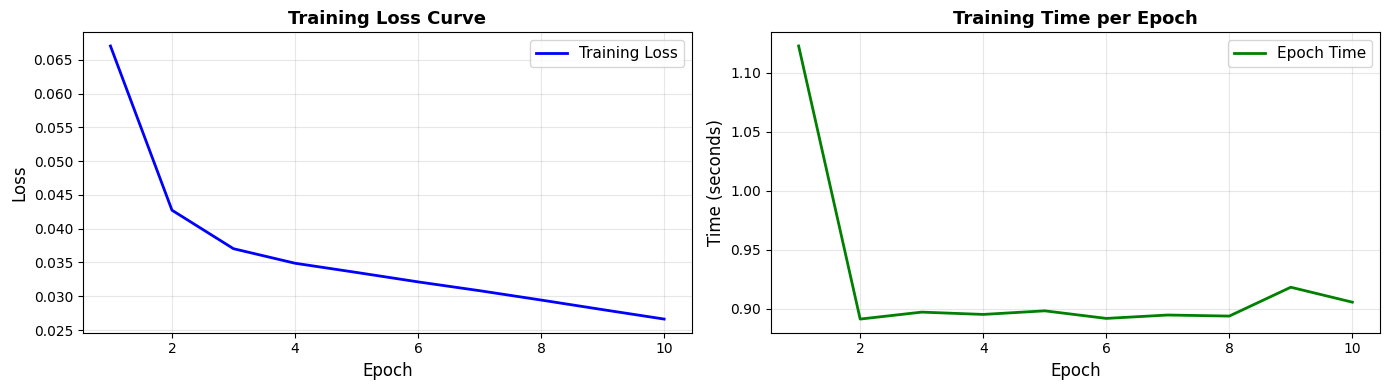

✓ Training curves displayed


In [89]:
# 绘制训练损失曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# 损失曲线
ax1.plot(range(1, num_epochs + 1), losses, "b-", linewidth=2, label="Training Loss")
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("Training Loss Curve", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# 计算每个 epoch 的平均时间
ax2.plot(range(1, num_epochs + 1), times, "g-", linewidth=2, label="Epoch Time")
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Time (seconds)", fontsize=12)
ax2.set_title("Training Time per Epoch", fontsize=13, fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Training curves displayed")

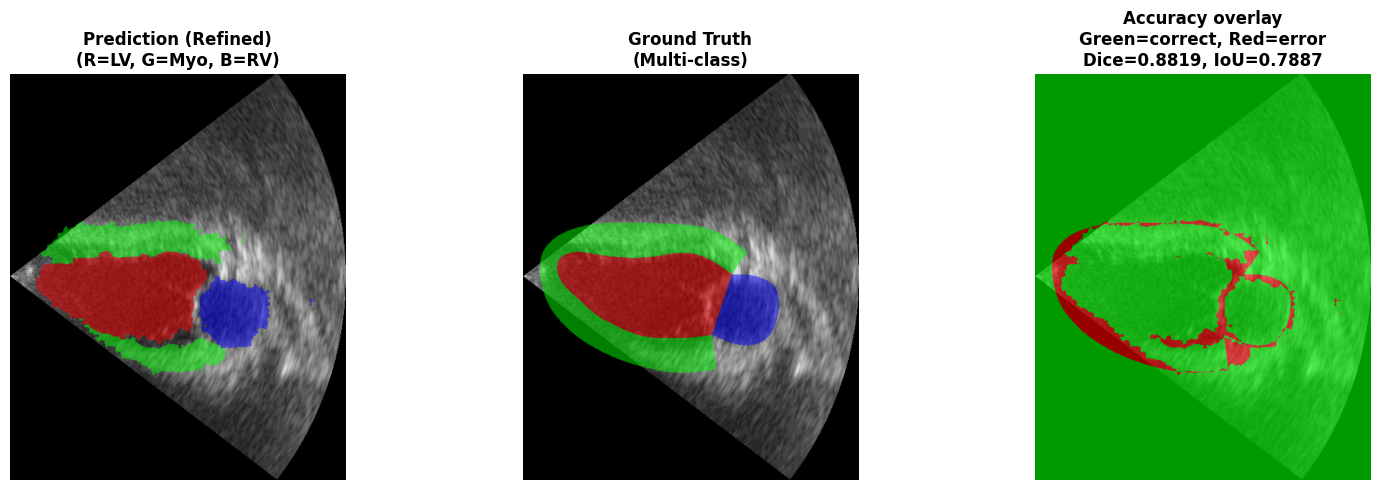

✓ Prediction vs GT comparison displayed


In [90]:
# 辅助函数：将掩膜转换为彩色图像
def mask_to_colored_image(mask, class_colors):
    """将多类掩膜转换为 RGB 彩色图像"""
    H, W = mask.shape
    colored = np.zeros((H, W, 3), dtype=np.uint8)
    for class_id, color in class_colors.items():
        colored[mask == class_id] = color
    return colored

def overlay_mask_on_image(image_gray, mask_colored, alpha=0.5):
    """将彩色掩膜叠加在灰度图像上"""
    # 确保图像是 uint8
    if image_gray.max() <= 1.0:
        image_gray = (image_gray * 255).astype(np.uint8)
    else:
        image_gray = image_gray.astype(np.uint8)
    
    # 转换为 RGB
    image_rgb = np.stack([image_gray, image_gray, image_gray], axis=2)
    
    # 找出非黑色像素
    mask_foreground = mask_colored.sum(axis=2) > 0
    
    # 混合
    blended = image_rgb.copy().astype(np.float32)
    blended[mask_foreground] = (
        image_rgb[mask_foreground].astype(np.float32) * (1 - alpha) +
        mask_colored[mask_foreground].astype(np.float32) * alpha
    )
    
    return blended.astype(np.uint8)

# Select refined mask if available
if "pred_multi_label_val_refined" in globals():
    pred_mask_to_show = pred_multi_label_val_refined
    mask_label = "Prediction (Refined)"
else:
    pred_mask_to_show = pred_multi_label_val
    mask_label = "Prediction"

# 生成彩色分割图
pred_colored = mask_to_colored_image(pred_mask_to_show, CLASS_COLORS)
pred_overlay = overlay_mask_on_image(image_raw, pred_colored, alpha=0.5)

if gt_multi_class is not None:
    gt_colored = mask_to_colored_image(gt_resized, CLASS_COLORS)
    gt_overlay = overlay_mask_on_image(image_raw, gt_colored, alpha=0.5)
    
    # 计算预测准确率
    error_map = np.logical_xor(pred_mask_to_show > 0, gt_resized > 0).astype(np.uint8)
    accuracy_colored = np.zeros((H, W, 3), dtype=np.uint8)
    accuracy_colored[error_map == 0] = [0, 255, 0]    # Green - correct
    accuracy_colored[error_map == 1] = [255, 0, 0]    # Red - error
    accuracy_overlay = overlay_mask_on_image(image_raw, accuracy_colored, alpha=0.6)
    
    # 绘制对比图
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    axes[0].imshow(pred_overlay)
    axes[0].set_title(f"{mask_label}\n(R=LV, G=Myo, B=RV)", fontsize=12, fontweight="bold")
    axes[0].axis("off")
    
    axes[1].imshow(gt_overlay)
    axes[1].set_title("Ground Truth\n(Multi-class)", fontsize=12, fontweight="bold")
    axes[1].axis("off")
    
    axes[2].imshow(accuracy_overlay)
    axes[2].set_title(
    f"Accuracy overlay\nGreen=correct, Red=error\nDice={overall_dice:.4f}, IoU={overall_iou:.4f}",
        fontsize=12,
        fontweight="bold",
    )
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Prediction vs GT comparison displayed")
else:
    # 仅显示预测结果
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(pred_overlay)
    ax.set_title(f"{mask_label}\n(R=LV, G=Myo, B=RV)", fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    
    print("✓ Prediction displayed")

## 总结

本 Notebook 展示了 MedSAM 点标注分割的完整训练流程：

1. **数据加载** - 从 NPZ 和 NII.GZ 文件加载 Patient0200 的图像、点标注和 GT
2. **模型推理** - 使用单个点进行分割推理，获得概率输出
3. **多点融合** - 通过加权优先级进行互斥分配，得到多类分割
4. **损失函数** - 实现点监督损失和边界对齐损失
5. **训练循环** - 执行简化的 epoch 训练，记录损失变化
6. **性能评估** - 计算 Dice、IoU 等指标
7. **结果可视化** - 对比预测结果和 GT，展示训练过程

关键要点：
- 点标注提供轻量级监督信号，比全像素标注更经济高效
- 边界对齐损失帮助模型学习分割边界的合理性
- 多点融合通过加权策略实现不同解剖结构的协调分割
- 定量指标（Dice、IoU）和定性可视化结合，全面评估性能